<a href="https://colab.research.google.com/github/Gaganatr29/ML-Lab/blob/main/Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install kaggle

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

 IMORTING FACEMASK DATASET

In [12]:
#Downloading the dataset(API Command)
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [18]:
from zipfile import ZipFile
dataset  = '/content/face-mask-dataset.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Extraction  was completed')

Extraction  was completed


In [19]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
from google.colab.patches import cv2_imshow
from PIL import Image

In [27]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[:5])
print(with_mask_files[-5:])

['with_mask_2571.jpg', 'with_mask_459.jpg', 'with_mask_3514.jpg', 'with_mask_731.jpg', 'with_mask_1039.jpg']
['with_mask_974.jpg', 'with_mask_2845.jpg', 'with_mask_3222.jpg', 'with_mask_2761.jpg', 'with_mask_3286.jpg']


In [28]:
print(len(with_mask_files))

3725


In [29]:
without_mask_files = os.listdir('/content/data/without_mask')

In [30]:
print(without_mask_files[:5])
print(without_mask_files[-5:])
print(len(without_mask_files))

['without_mask_1330.jpg', 'without_mask_1861.jpg', 'without_mask_865.jpg', 'without_mask_1648.jpg', 'without_mask_819.jpg']
['without_mask_2765.jpg', 'without_mask_3382.jpg', 'without_mask_444.jpg', 'without_mask_982.jpg', 'without_mask_3544.jpg']
3828


**creating the labels for both classes**

In [32]:
[1]*4


[1, 1, 1, 1]

In [35]:
with_mask_labels=[0]*3725

0 -->person with mask

1 -->person without mask

In [39]:
with_mask_labels = [0]*len(with_mask_files)
without_mask_labels = [1]*len(without_mask_files)

In [40]:
print(with_mask_labels)
print(len(with_mask_labels))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [41]:
print(without_mask_labels)
print(len(without_mask_labels))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

**Displaying the image**

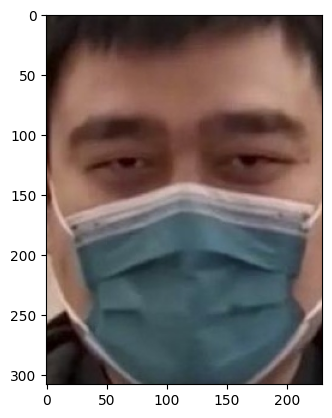

In [60]:
import matplotlib.image as mpimg
img = mpimg.imread('/content/data/with_mask/with_mask_459.jpg')
mask = plt.imshow(img)
plt.show()

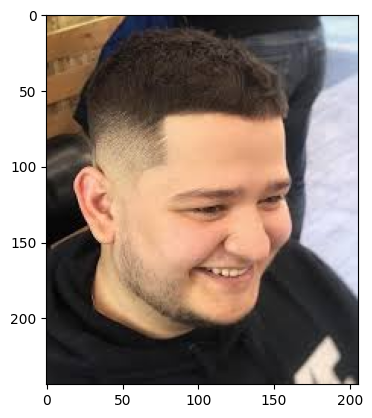

In [59]:
import matplotlib.image as mpimg
img = mpimg.imread('/content/data/without_mask/without_mask_3382.jpg')
mask = plt.imshow(img)
plt.show()

All images having different dimensions

**Image Processing**

In [74]:
#Convert imgs into array
from PIL import Image
import os
with_mask_path = '/content/data/with_mask'


informaton = []

for img_file in with_mask_path:
  IMG = Image.open(with_mask_path + img_file)


IsADirectoryError: [Errno 21] Is a directory: '/content/data/with_mask/'